# LOGISTIC REGRESSION

1. Why we need to move from Linear to Logistic Regression?<br>
2. Why it is called Logistic Regression 
3. Math behind Logistic Regression
4. Sigmoid Function with Calculation
5. Understanding m & c values
6. Confusion Matrix
7. Evaluation Metrics
8. End-to-end Logistic
9. Real time examples


# 1. Why we need to move from Linear to Logistic Regression?

--->Linear Reg predicts continuous values.<br>
Ex: Salary Prediction,House price prediction,Marks prediction.

But what if we want:<br>
   1.pass/fail<br>
   2.spam/not spam<br>
   3.disease/no disease.These are classification problems<br>
Linear Regression may predict:<br>
1.8,-2.5,0.8
which doesnt make sense for the classification.So we need output between 0 and 1.That is why we use the Logistic Regression.

# 2. Why it is called Logistic Regression?<br>

Logistic Reg uses a regression equation internally:<br>
z=mx+c<br>
Then it applies special function calles Sigmoid function to convert the output between 0 and 1.<br>
Sigmoid function: y=1/(1+e^-z)<br>
This converts the values from -infinity to +infinity into 0 to 1.<br>
Hence,it performs classification using regression mathematics.

# 3. Math behind Logistic Regression<br>
Equation : z=mx+c<br>
where , m=slope<br>
        c=intercept<br>
        x=input<br>
ex:m=2,c=-6<br>
Then, z=2x-6<br>
Code: x=4<br>
    z=(m*x)+c<br>
    print("m value:",m)<br>
    print("c value:",c)<br>
    print("z value:",z)<br>
    print("x value:",x)<br>
Sigmoid Function Calculation:<br>

import math<br>
z=2
sigmoid=1/(1+math.exp(-z))<br>
print("z value:",z)<br>
print("Sigmoid Probability:",sigmoid)<br>
If probability > 0.5:<br>
    class=1<br>
else:<br>
    class=0<br>
probability=sigmoid<br>
if probability > 0.5:
    print("Prediction: Pass (Class 1)")<br>
else:<br>
    print("Prediction: Fail (Class 0)")<br>

In [1]:
import math
z = 2
sigmoid = 1 / (1 + math.exp(-z))
print("z value:", z)
print("Sigmoid Probability:", sigmoid)
probability = sigmoid
if probability > 0.5:
    prediction_class = 1
else:
    prediction_class = 0
if probability > 0.5:
    print("Prediction: Pass (Class 1)")
else:
    print("Prediction: Fail (Class 0)")

z value: 2
Sigmoid Probability: 0.8807970779778823
Prediction: Pass (Class 1)


# Visualizing the Sigmoid Curve

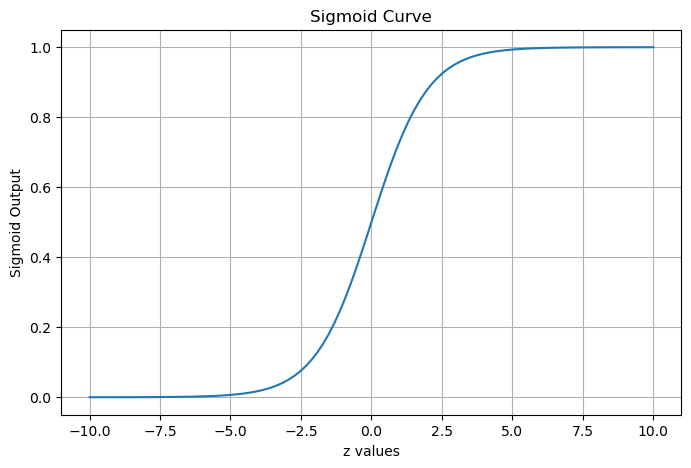

In [2]:
import matplotlib.pyplot as plt
import numpy as np
x=np.linspace(-10,10,100)
y=1/(1+np.exp(-x))
plt.figure(figsize=(8,5))
plt.plot(x,y)
plt.xlabel('z values')
plt.ylabel('Sigmoid Output')
plt.title('Sigmoid Curve')
plt.grid(True)
plt.show()

# Confusion Matrix 
Actual ||| Predicted  |||  Result <br>
1     |||     1       |||    True Positive<br>
1     |||     0       |||    False Negative<br>
0     |||     1       |||    False Positive<br>
0     |||     0       |||    True Negative<br>

# Evaluation Metrics<br>
1.Accuracy=(TP+TN)/(TP+TN+FP+FN)<br>
2.Precision=TP/(TP+FP)<br>
3.Recall=TP/(TP+FN)<br>
4.F1 Score=2*(Precision*Recall)/(Precision+Recall)<br>



# Logistic Regression End-to-end 
Project Name : Student Pass/Fail Prediction<br>
Features: <br>
   Study Hours<br>
Target:<br>
   Pass/Fail<br>


In [3]:
# Importing Libraries
import pandas as pd
import numpy as np
# Create dataset
data={'Study Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Pass': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]}
df=pd.DataFrame(data)
print(df)

   Study Hours  Pass
0            1     0
1            2     0
2            3     0
3            4     0
4            5     1
5            6     1
6            7     1
7            8     1
8            9     1
9           10     1


In [4]:
# Seperate Independent and Dependet Variables
x=df[["Study Hours"]]
y=df[["Pass"]]
print(x)
print(y)

   Study Hours
0            1
1            2
2            3
3            4
4            5
5            6
6            7
7            8
8            9
9           10
   Pass
0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     1
9     1


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training datasize:",len(x_train))
print("Testing datasize:",len(x_test))


Training datasize: 8
Testing datasize: 2


In [6]:
# Train Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
print("Model Trained Successfully")


Model Trained Successfully


c:\Users\NANDISHWAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [7]:
# Calculate m & c values
m = model.coef_[0][0]
c=model.intercept_[0]
print("m value:",m)
print("c value:",c)


m value: 1.1188238520249385
c value: -4.961982702816975


In [8]:
x = 5
z = m * x + c
print("For x=",x)
print("Calculated z value:", z)
probability = 1 / (1+math.exp(-z))
print("Probability:",probability)
if probability > 0.5:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")
y_pred = model.predict(x_test)
print("Predictions:",y_pred)

For x= 5
Calculated z value: 0.6321365573077173
Probability: 0.65297376210517
Prediction: Pass
Predictions: [1 0]


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test.values.ravel(),
    "Predicted": y_pred
})
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test.values.ravel(), y_pred)
print(cm)

[[1 0]
 [0 1]]


In [10]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred)
print("Precidion:",precision)
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred)
print("Recall:",recall) 
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred)
print("F1 Score:",f1)
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print("Classification Report:\n",report)

Accuracy: 1.0
Precidion: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

